# Observable vs. Unobservable States: Monocamera System
This example demonstrates the difference between observable and unobservable states using a simplified monocamera system. The system models a vehicle flying over terrain with two states: groundspeed and height. A single sensor—a monocamera—provides optic flow measurements, which correspond to the ratio of groundspeed to height.

The dynamics are trivial: the system states are directly controlled by sinusoidal inputs that activate one axis at a time. However, the nonlinear measurement function introduces a critical observability challenge: the optic flow alone cannot distinguish between certain combinations of height and speed. This makes the system only partially observable, and highlights the importance of understanding observability in sensor-driven estimation.

We will use this setup to visualize how the lack of full observability impacts state estimation and uncertainty over time.

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from pykal.system import System
from numpy.typing import NDArray
from typing import Callable

## Monocamera

def sinusoidal_control_input_with_params(
    amplitude: float = 10.0,
    frequency: float = 1.0,
    t_switch: float = 5.0
) -> Callable[[float], NDArray]:
    omega = 2 * np.pi * frequency

    def control_input(t: float) -> NDArray:
        if t < t_switch:
            return np.array([[amplitude * np.sin(omega * t), 0.0]]).T
        else:
            return np.array([[0.0, amplitude * np.sin(omega * t)]]).T

    return control_input

def camera_dynamics(u:NDArray) -> NDArray:  # no system dynamics, just passthrough
    return u

def optic_flow_sensor(x:NDArray) -> NDArray: #
    groundspeed, height = x[0][0], x[1][0]
    if height <=  0:
        raise ValueError(f"height cannot be less than or equal to 0, got {height}")
    optic_flow = np.array([[groundspeed/height]])
    return optic_flow


state_names = ["groundspeed", "height"]
measurement_names = ["optic_flow"]
sys = System(
f= camera_dynamics,
h = optic_flow_sensor,
u = sinusoidal_control_input_with_params(),
Q = System.zero_Q(state_names=state_names),
R = System.zero_R(measurement_names=measurement_names),
state_names=state_names,
measurement_names=measurement_names,
input_names=['horizontal_force','vertical_force'],
 system_type="cti")


## Simulating the Monocamera System

In this example, we simulate the monocamera system starting from an initial state with a fixed height and zero groundspeed. The sinusoidal control input drives the system, first horizontally and then vertically, revealing how the states evolve over time. The amplitude and frequency of the control input, and even the time at which it switches from the horizontal mode to the vertical, are parameters that can be temporarily changed and visualized.

<Axes: title={'center': 'State Trajectories'}, xlabel='Time', ylabel='State Value'>

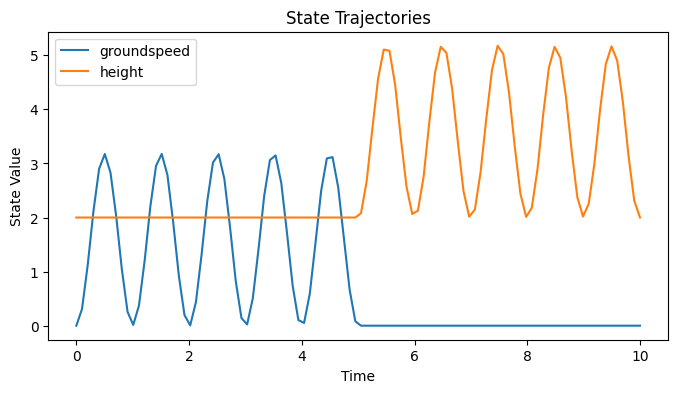

In [58]:
x0 = np.array([[0], [2]])
T = np.linspace(0,10,100)
X_df = sys.simulate_states(x0=x0, t_vector=T, 
                           override_system_Q=False,
                           override_system_f=sinusoidal_control_input_with_params(amplitude=10,frequency=1,t_switch=5),
                           output_df=True)
X_df.plot(title="State Trajectories", xlabel="Time", ylabel="State Value", figsize=(8, 4))

Using the previously simulated state trajectories, we can now generate the corresponding sensor measurements from the monocamera. The optic flow sensor observes only the ratio of groundspeed to height. Note how the sensor can give **no** information about the height of the system while the monocamera is vertically driven. 

<Axes: title={'center': 'Measureument Trajectory'}, xlabel='Time', ylabel='Value'>

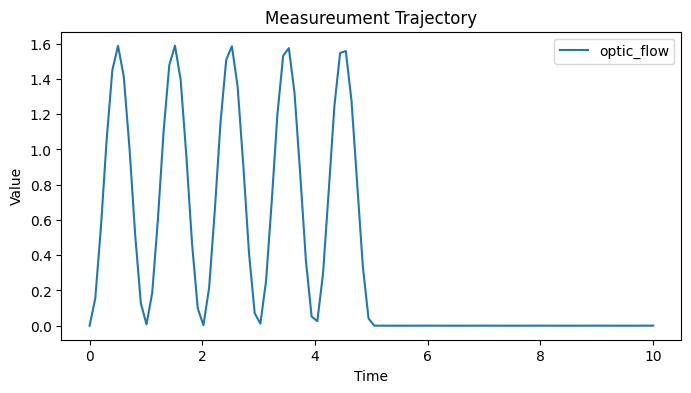

In [31]:
Y_df = sys.simulate_measurements(X_df=X_df, override_system_R=False,input_df=True,output_df =True)
Y_df.plot(title="Measureument Trajectory", xlabel="Time", ylabel="Value", figsize=(8, 4))

We can visualize the measurement trajecoctory superimposed upon the state trajectories to get an intuitive feel for the entire dynamical system. 

<Axes: title={'center': 'True vs Measured State Values '}, xlabel='time', ylabel='Values'>

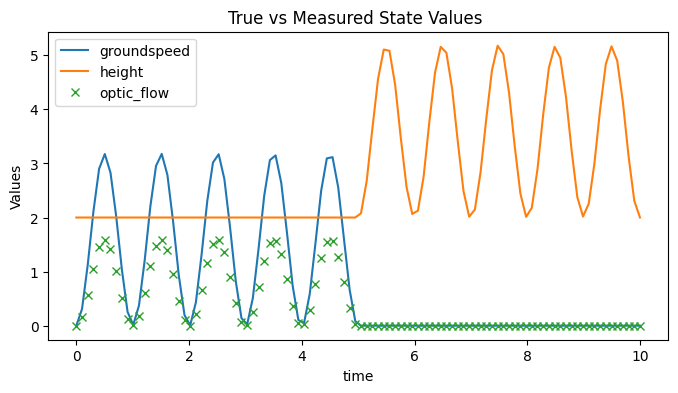

In [32]:
ax = X_df.plot(
      title="True vs Measured State Values ", xlabel="Time", ylabel="Values", figsize=(8, 4)
  )
ax.grid(True)  
Y_df.plot(ax=ax, style="x")

## Investigating Observability
With the `Observer` class, we can now investigate the observability structure of the monocamera system. 

In [33]:
from pykal.observer import Observer
from pykal.utils.compute import compute_eigenvalues_and_eigenvectors_of_grammian, compute_condition_number_from_eigenvalues, plot_observability_directions_from_eigenpairs
obs = Observer(sys)

We first compute the empirical observability Gramian (constructed from the empirical observability matrix). The matrix is full rank, so the system is observable. Further, the CN is low. 

In [34]:
W = obs.compute_observability_grammian_from_observability_matrix(x0=x0,t_vector=T) # grammian
W

array([[57.55887254, -9.04886093],
       [-9.04886093, 11.78204456]])

In [35]:
eigvals, eigvec = compute_eigenvalues_and_eigenvectors_of_grammian(W)

In [36]:
compute_condition_number_from_eigenvalues(eigvals)

np.float64(5.893942467881152)

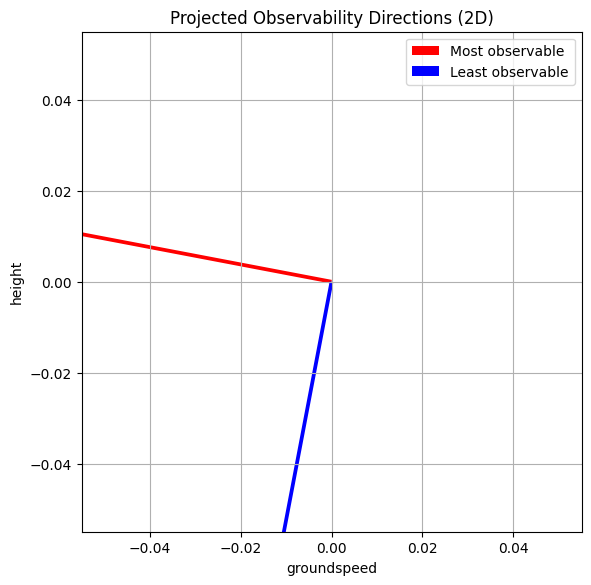

In [37]:
plot_observability_directions_from_eigenpairs(eigvals,eigvec,state_names=obs.sys.state_names)

Interesting. But now supposed we only restricted ourselves to the observability of the vertical control portion. 

In [38]:
W = obs.compute_observability_grammian_from_observability_matrix(x0=x0,t_vector=T[50:100]) # grammian
W

array([[5.80219029, 0.        ],
       [0.        , 0.        ]])

In [39]:
eigvals, eigvec = compute_eigenvalues_and_eigenvectors_of_grammian(W)

In [40]:
compute_condition_number_from_eigenvalues(eigvals)

inf

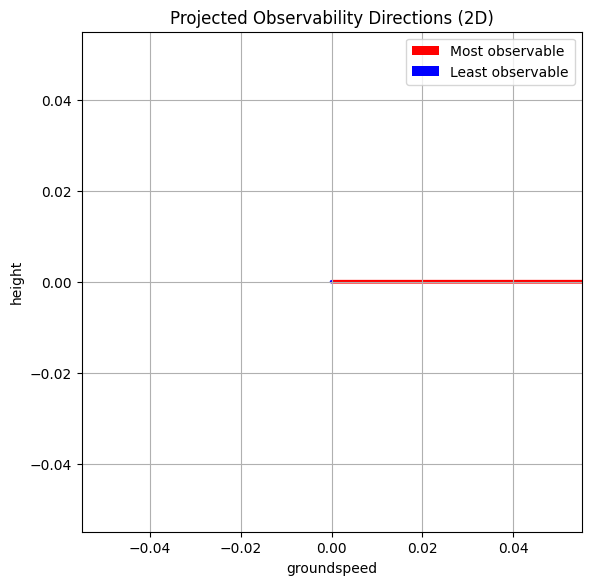

In [41]:
plot_observability_directions_from_eigenpairs(eigvals,eigvec,state_names=obs.sys.state_names)

Groundspeed is observable, but height is not! We can also use the nullspace method to quantify this.

In [42]:
obs.compute_state_observability_from_observability_grammian_nullspace(W=W,output_sr=True)

groundspeed    1.0
height         0.0
Name: Observability Index, dtype: float64

Lets now look over the whole trajectory, split into the two different driving modes.

In [43]:
state_observability_over_time = obs.compute_state_observability_over_time_using_observability_matrix_based_method(x0=x0,t_vector=T,divide_time_into_k_windows=2,observability_metric_of_states=obs.compute_state_observability_from_observability_grammian_nullspace,output_df=True)
state_observability_over_time

state_observability,groundspeed,height
time,,
0.00000,1.0,1.0
0.10101,1.0,1.0
0.20202,1.0,1.0
0.30303,1.0,1.0
0.40404,1.0,1.0
...,...,...
9.59596,1.0,0.0
9.69697,1.0,0.0
9.79798,1.0,0.0


<Axes: xlabel='time'>

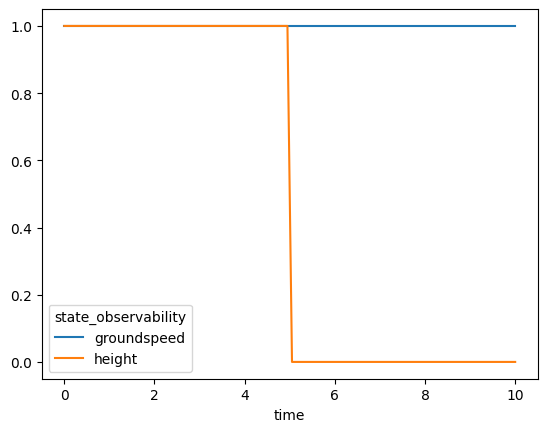

In [44]:
state_observability_over_time.plot()

We now try another method, stochastic observability

In [76]:
def test_Q(noise_in_groundspeed: float = 0.1, noise_in_height: float = 0.1):
    def Q() -> NDArray:
        return np.diag([noise_in_groundspeed, noise_in_height])
    
    return Q

def test_R(noise_in_optic_flow: float = 1):
    def R() -> NDArray:
        return np.diag([noise_in_optic_flow])
    
    return R
sys.Q = test_Q()
X_df = sys.simulate_states(x0=x0, t_vector=T,output_df=True)
sys.R = test_R()
Y_df = sys.simulate_measurements(X_df=X_df,input_df=True,output_df =True)

In [77]:
x0

array([[0],
       [2]])

In [78]:
P0 = np.eye(2) 
sys.F = sys.compute_jacobian_wrt_x(sys.f)
sys.H = sys.compute_jacobian_wrt_x(sys.h)
obs = Observer(sys)
x_est = x0 + np.random.multivariate_normal(mean=[0, 0], cov=P0).reshape(2,1)
X_est_df, P_est_sr = obs.ekf.run(x0=x_est,P0=P0,Y_df=Y_df, input_df=True, output_df=True)

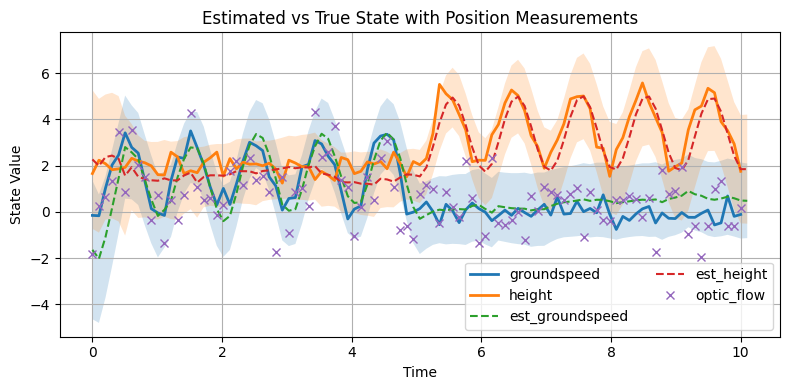

In [79]:
fig, ax = plt.subplots(figsize=(8, 4))

# Plot true states
X_df.plot(ax=ax, linewidth=2)

# Plot estimates (dashed)
X_est_df.plot(ax=ax, linestyle="--")

# Plot measurements
Y_df.plot(ax=ax, style="x")

# Add ±3σ confidence intervals for each state
for i, col in enumerate(X_est_df.columns):
    mean = X_est_df[col]
    std = np.sqrt([P[i, i] for P in P_est_sr])  # assumes P_est is a list of (n, n) cov matrices
    ax.fill_between(
        X_est_df.index,
        mean - 3 * std,
        mean + 3 * std,
        alpha=0.2,
    )

ax.set_title("Estimated vs True State with Position Measurements")
ax.set_xlabel("Time")
ax.set_ylabel("State Value")
ax.grid(True)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Beta'}, xlabel='time'>

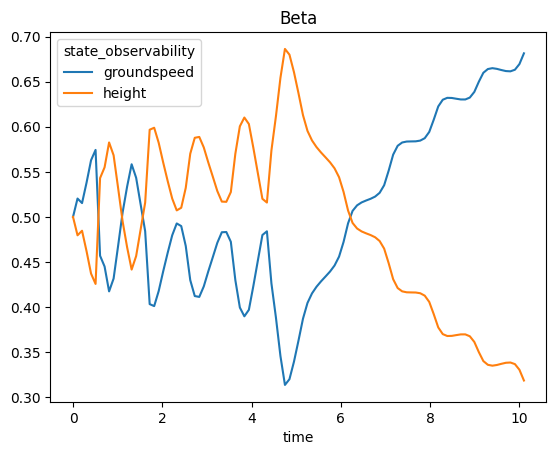

In [80]:
obs.compute_state_observability_over_time_using_P_matrix_based_method(P_series=P_est_sr,output_df=True).plot(title="Beta")


We need to include the beta in the updates. We can do it like so:

In [84]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray

def dynamic_beta_logger(eps: float = 1e-12):
    """
    Returns a `beta(t, Pk)` function that logs every output into an internal DataFrame.

    Parameters
    ----------
    eps : float
        Small constant to avoid division by zero.

    Returns
    -------
    Callable
        A function beta(t: float, Pk: NDArray) -> NDArray that logs its outputs.
    """
    log_df = pd.DataFrame()

    def beta(*,t: float, Pk: NDArray = None) -> NDArray:
        nonlocal log_df

        diag = np.diag(Pk)
        inv_diag = 1.0 / (diag + eps)
        inv_diag /= np.sum(inv_diag)
        inv_diag = np.clip(inv_diag, 0.0, 1.0)
        beta_vec = inv_diag.reshape(-1, 1)
        print(beta_vec)
        # Store result in log
        log_df[t] = inv_diag  # one column per time, rows are states
        return beta_vec

    # Attach log accessor to function
    beta.get_log_df = lambda: log_df.T  # return states x time for readability
    return beta


In [88]:
def beta_freeze() -> NDArray:
        return np.array([[0],[1]])

In [90]:
beta_freeze().shape

(2, 1)

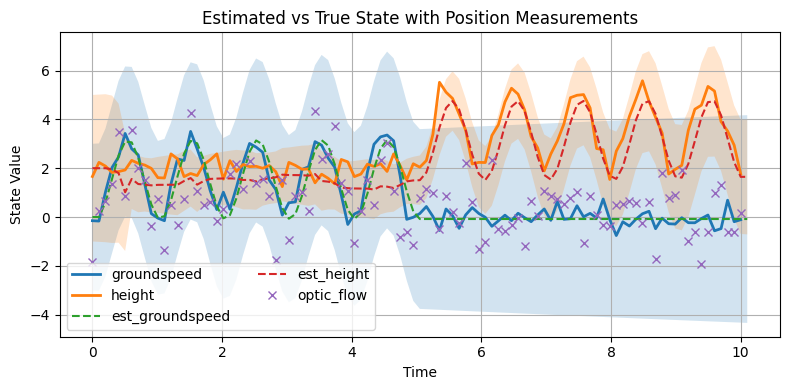

In [91]:
def beta_freeze() -> NDArray:
        return np.array([[0],[1]])
dynamic_beta = dynamic_beta_logger()
X_est_df, P_est_sr = obs.ekf.run(x0=x0,P0=P0,Y_df=Y_df, input_df=True, output_df=True,override_system_beta=beta_freeze)

fig, ax = plt.subplots(figsize=(8, 4))

# Plot true states
X_df.plot(ax=ax, linewidth=2)

# Plot estimates (dashed)
X_est_df.plot(ax=ax, linestyle="--")

# Plot measurements
Y_df.plot(ax=ax, style="x")

# Add ±3σ confidence intervals for each state
for i, col in enumerate(X_est_df.columns):
    mean = X_est_df[col]
    std = np.sqrt([P[i, i] for P in P_est_sr])  # assumes P_est is a list of (n, n) cov matrices
    ax.fill_between(
        X_est_df.index,
        mean - 3 * std,
        mean + 3 * std,
        alpha=0.2,
    )

ax.set_title("Estimated vs True State with Position Measurements")
ax.set_xlabel("Time")
ax.set_ylabel("State Value")
ax.grid(True)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

In [92]:
beta_log_df = dynamic_beta.get_log_df()
beta_log_df.plot(title="Beta")

TypeError: no numeric data to plot

In [52]:
def make_dynamic_nullspace_beta(
    obs,
    update_interval: float = 2.0,
    window_duration: float = 2.0,
    N: int = 25  # number of samples for Gramian computation
) -> Callable[[float, NDArray], NDArray]:
    """
    Create a dynamic beta function that recomputes β every `update_interval` seconds
    using the nullspace of the observability Gramian over a moving time window.

    The function logs β values for *every time step* in the EKF run, using the
    actual time vector as the DataFrame index. It logs the `t_start`, `t_end` of
    the update window, which are repeated until the next β update.

    Returns
    -------
    beta_fn : Callable[[float, NDArray], NDArray]
        Function β(t, x) to use in EKF. Exposes `.get_log_df()` to access full log.
    """
    last_update_time = -np.inf
    last_beta = None
    t_start_last = np.nan
    t_end_last = np.nan

    # Prepare column names
    state_names = obs.sys.state_names
    log_cols = state_names + ["t_start", "t_end"]
    log_df = pd.DataFrame(columns=log_cols)

    def beta(t: float, x: NDArray) -> NDArray:
        nonlocal last_update_time, last_beta, log_df, t_start_last, t_end_last

        # Don't compute Gramian until there's enough time history
        if t < window_duration:
            if last_beta is None:
                last_beta = np.ones((x.shape[0], 1))  # fallback default
            beta_row = list(last_beta.ravel()) + [t_start_last, t_end_last]
            log_df.loc[t] = beta_row
            return last_beta

        t0 = t - window_duration

        if (t - last_update_time) >= update_interval or last_beta is None:
            t_vector = np.linspace(t0, t, N)

            # Compute Gramian and β
            W = obs.compute_observability_grammian_from_observability_matrix(
                x0=x, t_vector=t_vector
            )
            beta_vec = obs.compute_state_observability_from_observability_grammian_nullspace(
                W=W, output_sr=False
            ).reshape(-1, 1)

            last_beta = beta_vec
            last_update_time = t
            t_start_last = t0
            t_end_last = t

        # Log β for every t
        beta_row = list(last_beta.ravel()) + [t_start_last, t_end_last]
        log_df.loc[t] = beta_row

        return last_beta

    beta.get_log_df = lambda: log_df.sort_index()
    return beta



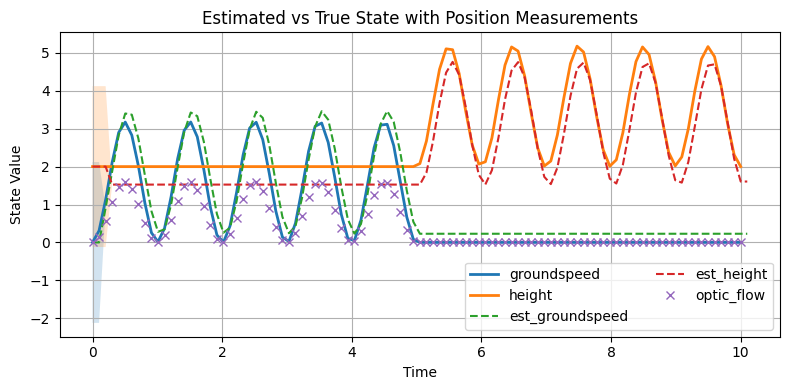

In [53]:
sys.Q = System.zero_Q(state_names)
X_df = sys.simulate_states(x0=x0, t_vector=T,output_df=True)
sys.R = System.zero_R(measurement_names)
Y_df = sys.simulate_measurements(X_df=X_df,input_df=True,output_df =True)

obs = Observer(sys)
dynamic_beta_nullspace = make_dynamic_nullspace_beta(obs)
X_est_df, P_est_sr = obs.ekf.run(x0=x0,P0=P0,Y_df=Y_df, input_df=True, output_df=True,override_system_beta=dynamic_beta_nullspace)

fig, ax = plt.subplots(figsize=(8, 4))

# Plot true states
X_df.plot(ax=ax, linewidth=2)

# Plot estimates (dashed)
X_est_df.plot(ax=ax, linestyle="--")

# Plot measurements
Y_df.plot(ax=ax, style="x")

# Add ±3σ confidence intervals for each state
for i, col in enumerate(X_est_df.columns):
    mean = X_est_df[col]
    std = np.sqrt([P[i, i] for P in P_est_sr])  # assumes P_est is a list of (n, n) cov matrices
    ax.fill_between(
        X_est_df.index,
        mean - 3 * std,
        mean + 3 * std,
        alpha=0.2,
    )

ax.set_title("Estimated vs True State with Position Measurements")
ax.set_xlabel("Time")
ax.set_ylabel("State Value")
ax.grid(True)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

In [54]:
beta_log_df = dynamic_beta_nullspace.get_log_df()
beta_log_df

,groundspeed,height,t_start,t_end
0.00000,1.0,1.0,NaN,NaN
0.10101,1.0,1.0,NaN,NaN
0.20202,1.0,1.0,NaN,NaN
0.30303,1.0,1.0,NaN,NaN
0.40404,1.0,1.0,NaN,NaN
...,...,...,...,...
9.59596,1.0,1.0,6.080808,8.080808
9.69697,1.0,1.0,6.080808,8.080808
9.79798,1.0,1.0,6.080808,8.080808
9.89899,1.0,1.0,6.080808,8.080808


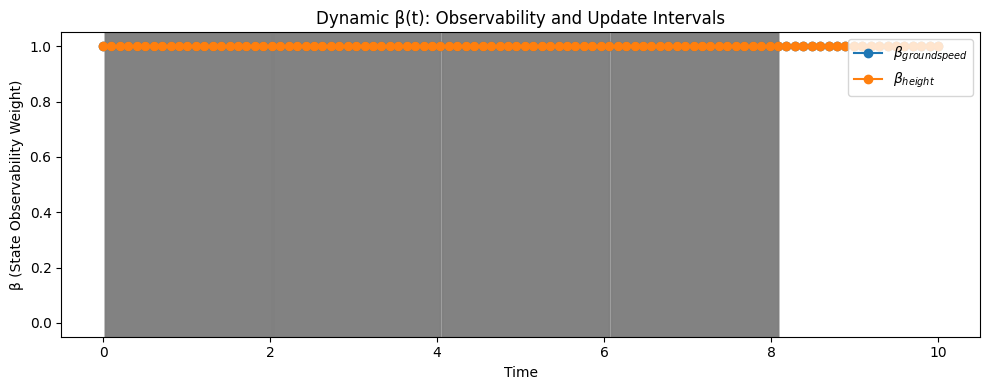

In [55]:
# Extract logged beta DataFrame from the beta function
beta_log = dynamic_beta_nullspace.get_log_df()

# Create plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot each state’s beta value over time
for state in obs.sys.state_names:
    ax.plot(beta_log.index, beta_log[state], label=fr"$\beta_{{{state}}}$", marker="o")

# Overlay shaded rectangles showing update intervals
for _, row in beta_log.iterrows():
    t_start = row["t_start"]
    t_end = row["t_end"]
    ax.axvspan(t_start, t_end, color="gray", alpha=0.15)

# Annotate plot
ax.set_title("Dynamic β(t): Observability and Update Intervals")
ax.set_xlabel("Time")
ax.set_ylabel("β (State Observability Weight)")
ax.set_ylim([-0.05, 1.05])
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [56]:
t_vector = np.linspace(6.080808, 8.080808, 25)
W = obs.compute_observability_grammian_from_observability_matrix(x0=x0,t_vector=t_vector) # grammian
W

array([[3.26795527, 0.        ],
       [0.        , 0.        ]])